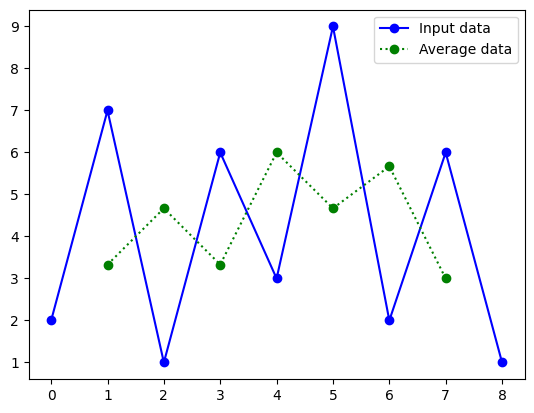

In [2]:
# 교재 86P  이동평균 시각화 

data1 = [2, 7, 1, 6, 3, 9, 2, 6 ,1]
data2=[None, 3.33, 4.67, 3.33, 6.00, 4.67, 5.67, 3.00, None]
import matplotlib.pyplot as plt
plt.plot(data1, 'bo-', label='Input data')
plt.plot(data2, 'go:', label='Average data')
plt.legend()


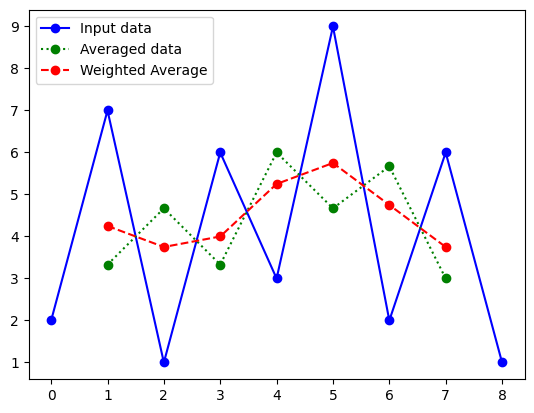

In [6]:
# 교재 88P  이동평균 시각화 

data1 = [2, 7, 1, 6, 3, 9, 2, 6 ,1]
data2=[None, 3.33, 4.67, 3.33, 6.00, 4.67, 5.67, 3.00, None]

h = [1/4, 1/2, 1/4]      # Filter Kernel
w_data2 = [None] 

for i in range(1, len(data1)-1):
    w_data2.append(data1[i-1]* h[0] + data1[i]*h[1] + 
                   data1[i+1]*h[2])

import matplotlib.pyplot as plt
plt.plot(data1, 'bo-', label='Input data')
plt.plot(data2, 'go:', label='Averaged data')
plt.plot(w_data2, 'ro--', label='Weighted Average')
plt.legend()

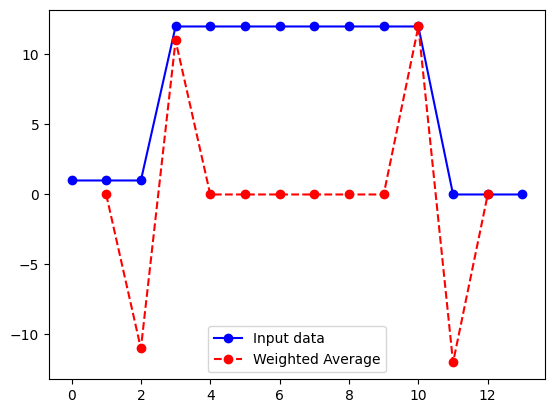

In [6]:
# 교재 89P  엣지검출 시각화 

data = [1, 1, 1,12, 12, 12, 12, 12, 12, 12, 12, 0,0,0]

h = [-1, 2, -1]      # Filter Kernel
w_ma_y = [None] 

for i in range(1, len(data)-1):
    w_ma_y.append(data[i-1]* h[0] + data[i]*h[1] + 
                   data[i+1]*h[2])

import matplotlib.pyplot as plt
plt.plot(data, 'bo-', label='Input data')
plt.plot(w_ma_y, 'ro--', label='Weighted Average')
plt.legend()


In [ ]:
# 94페이지 합성곱 함수구현 사례

import numpy as np 

def Conv2D(img, kernel=None, padding='valid'):
    if kernel is not None :
        h, w = img. shape[0:2]
        kh, kw = kernel.shape 
        sy, sx = int(kh/2), int(kw/2)
        if padding == 'same':
            new_shape =(h+sy, w+sx)
            img_out = np.zeros(new_shape, dtype=np.uint8)
        elif padding=='valid':
            img_out = np.zeros(img.shape, dtype=np.uint8)

        height, width = img_out.shape
        for y in range (sy, height-2*sy):
            for x in range (sx, width-2*sx):
                roi = img[y-sy:y+sy+1, x-sx:x+sx+1]
                filtered = roi * kernel
                conv_value = np.abs(np.sum(filtered))
                img_out[y,x] = np.uint8(conv_value)
        return img_out[sy:-sy, sx:-sx]
    else :
        print('kernel array not found!')


import cv2  # pip install opencv-python 

img = cv2.imread('house.jpg', cv2.IMREAD_GRAYSCALE)
kernel = np.array([[0,0,0],[0,1,-1],[0,0,0]])
output = Conv2D(img, kernel=kernel, padding='same')
cv2.imshow('house', img)
cv2.imshow('Conv2D', output)
cv2.waitKey()
cv2.destroyAllWindows()

In [ ]:
# 97페이지 합성곱 함수구현 사례

import numpy as np 

def maxpool2d(img):
    height, width = img.shape
    img_ = np.zeros((int(height/2), int(width/2)),dtype=np.uint8)
    for y in range (int(height/2)):
        for x in range (int(width/2)):
            try :
                img_[y,x] = np.max(img[2*y:2*y+2, 2*x:2*x+2])
            except:
                pass
    return img_

import cv2  
img = cv2.imread('house.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow("Original", img)
cv2.imshow('Nearest 0.5', cv2.resize(img, dsize=(0,0), fx=0.5, fy=0.5))
cv2.imshow('Max Pooling', maxpool2d(img))
cv2.waitKey(0) & 0xFF == 27          # 27 → ESC 키 ASCII 코드
cv2.destroyAllWindows()


In [6]:
import cv2  # pip install opencv-python 
img = cv2.imread('house.jpg', cv2.IMREAD_GRAYSCALE)
kernel = np.array([[0,0,0],[0,1,-1],[0,0,0]])
edge = cv2.filter2D(img, -1, kernel)
cv2.imshow("Original", img)
cv2.imshow('Nearest 0.5', maxpool2d(edge))
cv2.imshow('Max Pooling', maxpool2d(edge))
cv2.waitKey(0) & 0xFF == 27          # 27 → ESC 키 ASCII 코드
cv2.destroyAllWindows()

In [3]:
# chatGPT 코드 MNIST 그림 예 

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# CNN 모델 구성
model = Sequential()

# 입력: 28x28x1
# Conv1: 5x5 필터 10개, valid padding
# 출력: 24x24x10
model.add(Conv2D(
    filters=10,
    kernel_size=(5, 5),
    activation='relu',
    padding='valid',
    input_shape=(28, 28, 1)
))

# Max Pooling: 2x2
# 출력: 12x12x10
model.add(MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
))

# Conv2: 5x5 필터 20개
# 출력: 8x8x20
model.add(Conv2D(
    filters=20,
    kernel_size=(5, 5),
    activation='relu',
    padding='valid'
))

# Max Pooling: 2x2
# 출력: 4x4x20
model.add(MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
))

# Flatten: 4x4x20 = 320
model.add(Flatten())

# FC Layer: 100개 뉴런
model.add(Dense(100, activation='relu'))

# FC Layer: 10개 출력
model.add(Dense(10, activation='softmax'))

# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 구조 확인
model.summary()

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 20)       │         5,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        32,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,390 (149.96 KB)

 Trainable params: 38,390 (149.96 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# chatGPT 코드 MNIST 손글씨 구성도 그림 103페이지 

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# MNIST CNN 모델
model = Sequential()

# 입력: 28×28×1
# Conv1: 3×3 필터 32개 → 28×28×32
model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding='same',
    activation='relu',
    input_shape=(28, 28, 1)
))

# Max Pooling1: 28×28×32 → 14×14×32
model.add(MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
))

# Conv2: 3×3 필터 64개 → 14×14×64
model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))

# Max Pooling2: 14×14×64 → 7×7×64
model.add(MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
))

# Flatten: 7×7×64 = 3136
model.add(Flatten())

# Fully Connected: 3136 → 1024
model.add(Dense(1024, activation='relu'))

# Output: 1024 → 10
model.add(Dense(10, activation='softmax'))

# 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 구조 확인
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     3,212,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,241,354 (12.36 MB)

 Trainable params: 3,241,354 (12.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 95페이지 코드 

from tensorflow.keras import Sequential, layers
model = Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(), # pool_size=(2,2)가 기본값
    layers.Dropout(0.1)])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 108page 코딩 (padding 없음)

from tensorflow.keras import Sequential, layers
model = Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(), # pool_size=(2,2)가 기본값
    layers.Dropout(0.1),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 108page 코딩 (padding='same')

from tensorflow.keras import Sequential, layers
model = Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(), # pool_size=(2,2)가 기본값
    layers.Dropout(0.1),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.datasets import mnist
(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X.reshape(-1, 28, 28, 1) / 255.0 # 채널정보를 추가하고, 0~1 사이로 정규화
test_X = test_X.reshape(-1, 28, 28, 1) / 255.0 # 채널정보를 추가하고, 0~1 사이로 정규화

In [16]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])

In [17]:
hist=model.fit(train_X, train_y, validation_data=(test_X, test_y),
          batch_size=128, epochs=15, verbose=1)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8989 - loss: 0.3175 - val_accuracy: 0.9793 - val_loss: 0.0632
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9700 - loss: 0.1023 - val_accuracy: 0.9847 - val_loss: 0.0428
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9768 - loss: 0.0782 - val_accuracy: 0.9887 - val_loss: 0.0360
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9808 - loss: 0.0648 - val_accuracy: 0.9896 - val_loss: 0.0302
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9820 - loss: 0.0571 - val_accuracy: 0.9915 - val_loss: 0.0285
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9848 - loss: 0.0499 - val_accuracy: 0.9915 - val_loss: 0.0259
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9862 - loss: 0.0459 - val_accuracy: 0.9910 - val_loss: 0.0273
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9871 - loss: 0.0412 - 

In [18]:
loss, accuracy = model.evaluate(test_X, test_y, verbose=0)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

Test loss: 0.02348015457391739
Test accuracy: 0.9930999875068665


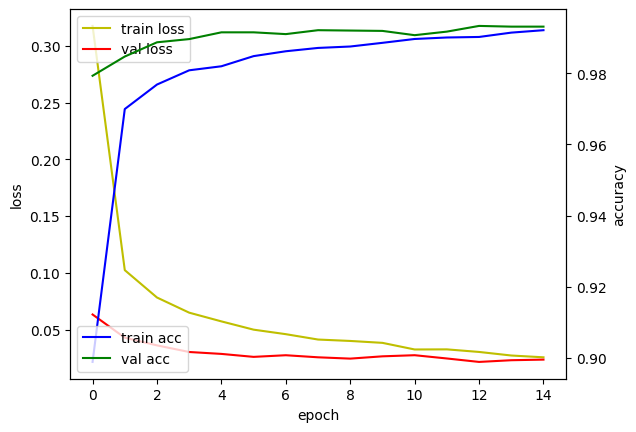

In [19]:
# 시각화 111페이지 

import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()
loss_ax.plot(hist.history['loss'],'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'b', label='train acc')
acc_ax.plot(hist.history['val_accuracy'],'g', label='val acc')
acc_ax.set_ylabel('accuracy')
acc_ax.legend(loc='lower left')

plt.show()


In [22]:
from tensorflow.keras.callbacks import TensorBoard
tensor_board = TensorBoard(log_dir='tensor_log', embeddings_freq=1, histogram_freq=1)

In [6]:
! pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Program Files\Python313\python.exe -m pip install --upgrade pip


In [8]:
import cv2
img = cv2.imread('number.png', cv2.IMREAD_GRAYSCALE)
print(img.shape)

(28, 28)


In [9]:
pred = model.predict(img.reshape(-1, 28,28,1))
import numpy as np
np.argmax(pred, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([8])

array([4])

In [10]:
from tensorflow.keras.applications import ResNet50
model = ResNet50(weights='imagenet')

In [11]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import decode_predictions
img = image.load_img('YellowLabradorLooking_new.jpg', target_size=(224,224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
pred = model.predict(x, verbose=0)
print('predicted:', decode_predictions(pred, top=5))

predicted: [[('n02099712', 'Labrador_retriever', np.float32(0.26897714)), ('n02108089', 'boxer', np.float32(0.15149584)), ('n02099849', 'Chesapeake_Bay_retriever', np.float32(0.10756556)), ('n02089867', 'Walker_hound', np.float32(0.06764958)), ('n02104029', 'kuvasz', np.float32(0.046868432))]]


In [1]:
# chatGPT 코드  MNIST 손글씨 CNN모델 (108페이지)

import tensorflow as tf
from tensorflow.keras import layers, models

# 1. 모델 구축
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 0~9 분류
])

# 2. 모델 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary() # 모델 구조 확인 



c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [1]:
# chatGPT CNN 모델링 코드 108페이지 

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# MNIST CNN 모델
model = Sequential()

# 입력: 28×28×1
# Conv1: 3×3 필터 32개 → 28×28×32
model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding='same',
    activation='relu',
    input_shape=(28, 28, 1)
))

# Max Pooling1: 28×28×32 → 14×14×32
model.add(MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
))

# Conv2: 3×3 필터 64개 → 14×14×64
model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))

# Max Pooling2: 14×14×64 → 7×7×64
model.add(MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
))

# Flatten: 7×7×64 = 3136
model.add(Flatten())

# Fully Connected: 3136 → 1024
model.add(Dense(1024, activation='relu'))

# Output: 1024 → 10
model.add(Dense(10, activation='softmax'))

# 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 구조 확인
model.summary()

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,212,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,241,354 (12.36 MB)

 Trainable params: 3,241,354 (12.36 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# GPU 장치 확인 및 설치 112 페이지   

from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 13755235012706330505
xla_global_id: -1
]


In [25]:
# GPU 장치 확인 및 설치 112 페이지    

import tensorflow as tf
tf.config.list_physical_devices("GPU")

[]

In [2]:
# LeNet Model 코드 117page  

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Input

class LeNet: 

    @staticmethod
    def build(input_shape=(32,32,1), activation='sigmoid'):
        model = Sequential()

        model.add(Input(shape=input_shape))

        # C1: 첫 번째 합성곱층 => ACTIVATION => POOL계층 
        model.add(Conv2D(6,5,activation=activation,
                         kernel_initializer='random_uniform'))
        model.add(AveragePooling2D(pool_size=(2,2)))

         # C3: 두 번째 합성곱층 => ACTIVATION => POOL계층 
        model.add(Conv2D(16,5,activation=activation,
                         kernel_initializer='random_uniform'))
        model.add(AveragePooling2D(pool_size=(2,2)))

        # FC 첫 번째 계층
        model.add(Flatten())
        model.add(Dense(120, activation=activation))

        # FC 두 번째 계층
        model.add(Dense(84, activation=activation))

        #출력층 softmax 함수 사용
        model.add(Dense(10, activation='softmax'))

        return model
    
model=LeNet.build(input_shape=(28,28,1), activation='relu')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# 훈련정의 

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd', metrics=['accuracy']) 

In [5]:
# MNIST DATA 업로드 

from tensorflow.keras.datasets import mnist

(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X.reshape(-1,28,28,1) / 255.0
test_X = test_X.reshape(-1,28,28,1) / 255.0 

In [6]:
# MODEL 학습

model.fit(train_X, train_y, batch_size=300, epochs=10)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2126 - loss: 2.2958
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2619 - loss: 2.2748
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3791 - loss: 2.1786
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6990 - loss: 1.1906
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8446 - loss: 0.5366
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8733 - loss: 0.4318
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8907 - loss: 0.3748
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9013 - loss: 0.3361
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9085 - loss: 0.3083
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9166 - loss: 0.2840


In [7]:
# MODEL 평가 

loss, accuracy = model.evaluate(test_X, test_y, verbose=0)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 91.25%


In [1]:
# chatGPT  현대 모델 LeNet-5 코드  

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D
from tensorflow.keras.layers import Flatten, Dense

model02 = Sequential([
    # 입력: 32×32 흑백 이미지
    Conv2D(
        filters=6,
        kernel_size=(5, 5),
        activation="tanh",
        input_shape=(28, 28, 1)      # MNIST 이미지 크기 (28x28) 설정
    ),

    AveragePooling2D(pool_size=(2, 2), strides=2),

    Conv2D(
        filters=16,
        kernel_size=(5, 5),
        activation="tanh"
    ),

    AveragePooling2D(pool_size=(2, 2), strides=2),

    # 5×5×16 → 400차원 벡터
    Flatten(),

    Dense(120, activation="tanh"),
    Dense(84, activation="tanh"),
    Dense(10, activation="softmax")
])

model02.summary()

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 훈련정의 

model02.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd', metrics=['accuracy']) 

In [2]:
# MNIST DATA 업로드 

from tensorflow.keras.datasets import mnist

(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X.reshape(-1,28,28,1) / 255.0
test_X = test_X.reshape(-1,28,28,1) / 255.0 

In [4]:
# MODEL 학습

model02.fit(train_X, train_y, batch_size=200, epochs=10)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6031 - loss: 1.5831
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8500 - loss: 0.6418
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8788 - loss: 0.4662
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8900 - loss: 0.4003
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8976 - loss: 0.3618
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9046 - loss: 0.3345
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9100 - loss: 0.3127
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9153 - loss: 0.2944
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9190 - loss: 0.2784
Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9233 - loss: 0.2642


In [5]:
# MODEL 평가 

loss, accuracy = model02.evaluate(test_X, test_y, verbose=0)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 92.99%


In [4]:
# LeNet Model 임의의 숫자 10개  120page 

# LeNet Model 클래스 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Input

class LeNet: 

    @staticmethod
    def build(input_shape=(32,32,1), activation='sigmoid'):
        model = Sequential()

        model.add(Input(shape=input_shape))

        # C1: 첫 번째 합성곱층 => ACTIVATION => POOL계층 
        model.add(Conv2D(6,5,activation=activation,
                         kernel_initializer='random_uniform'))
        model.add(AveragePooling2D(pool_size=(2,2)))

         # C3: 두 번째 합성곱층 => ACTIVATION => POOL계층 
        model.add(Conv2D(16,5,activation=activation,
                         kernel_initializer='random_uniform'))
        model.add(AveragePooling2D(pool_size=(2,2)))

        # FC 첫 번째 계층
        model.add(Flatten())
        model.add(Dense(120, activation=activation))

        # FC 두 번째 계층
        model.add(Dense(84, activation=activation))

        #출력층 softmax 함수 사용
        model.add(Dense(10, activation='softmax'))

        return model
    
model=LeNet.build(input_shape=(28,28,1), activation='relu')
# model.summary()


# 훈련 정의 

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd', metrics=['accuracy']) 

# MNIST DATA 업로드 

from tensorflow.keras.datasets import mnist

(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X.reshape(-1,28,28,1) / 255.0
test_X = test_X.reshape(-1,28,28,1) / 255.0 

# MODEL 학습
model.fit(train_X, train_y, batch_size=200, epochs=10)

import numpy as np
import cv2

samples = np.random.choice(np.arange(0,len(test_y)), size=(10,))

for i in samples:
    probs = model.predict(test_X[np.newaxis, i], verbose=0)
    prediction = probs.argmax(axis=1)

    image = (test_X[i]*255).astype('uint8')
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    image = cv2.resize(image,(96,96),
                       interpolation=cv2.INTER_LINEAR)

    cv2.putText(image, str(prediction[0]), (5,20),
                cv2.FONT_HERSHEY_COMPLEX, 0.75, (0,255,0), 2)
    print(f'Pridicted: {prediction[0]}, Actual: {test_y[i]}')
    cv2.imshow('Digit', image)

    key = cv2.waitKey(0)
    if key & 0xFF == 27:  # ESC를 누르면 종료
        break
    cv2.waitKey(0)

cv2.destroyAllWindows()

# test Model 저장
model.save('LeNet_MNIST.keras')

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2807 - loss: 2.2845
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6207 - loss: 1.4763
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8648 - loss: 0.4584
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8949 - loss: 0.3476
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9096 - loss: 0.2985
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9190 - loss: 0.2649
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9259 - loss: 0.2423
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9324 - loss: 0.2228
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9364 - loss: 0.2094
Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9402 - loss: 0.1954
Pridicted: 5, Actual: 5
Pridicted: 8, Actual: 8
Pridicted: 8, Actual: 8
Pridicted: 7, Actual: 7
Pridicted: 7, Actual: 7
Pridicted: 6, Actua